In [1922]:
#1. Importing and Exploring

In [1923]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [1924]:
#Loading CSVs

In [1925]:
#Two datasets will be used in this project, borrower profiles dataset and loan application dataset.
# Borrower profile dataset will be used directly to inform changes to their credit scoring model while loan appliaction dataset will be used to find the loan approval thresholds.

In [1926]:
df = pd.read_csv("/borrower_profiles.csv")
df

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608
...,...,...,...,...,...,...,...,...,...,...,...
495,BRW-0496,27,IL,Bachelor,Contract,4,60337,661,Mortgage,0,2359
496,BRW-0497,23,MO,High School,Full-Time,3,54617,773,Rent,3,1475
497,BRW-0498,30,CO,Doctorate,Self-Employed,7,85000,845,Mortgage,3,1894
498,BRW-0499,62,MA,Bachelor,Full-Time,14,62749,811,Rent,1,1339


In [1927]:
#Finding how many of the missing values exist

In [1928]:
df.isnull().sum()

,0
borrower_id,0
age,0
state,0
education_level,0
employment_status,0
years_employed,0
annual_income,0
credit_score,0
home_ownership,0
dependents,0


In [1929]:
#Finding shape of our borrowers data

In [1930]:
df.shape

(500, 11)

In [1931]:
#Finding information on borrower dataset

In [1932]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   borrower_id            500 non-null    object
 1   age                    500 non-null    int64 
 2   state                  500 non-null    object
 3   education_level        500 non-null    object
 4   employment_status      500 non-null    object
 5   years_employed         500 non-null    int64 
 6   annual_income          500 non-null    int64 
 7   credit_score           500 non-null    int64 
 8   home_ownership         500 non-null    object
 9   dependents             500 non-null    int64 
 10  existing_monthly_debt  500 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 43.1+ KB


In [1933]:
#Describing our borrower dataset

In [1934]:
df.describe()

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.986000,10.854000,64471.484000,704.952000,1.356000,1585.166000
std,13.539736,9.301706,28959.837645,97.339157,1.252358,1089.979915
min,22.000000,0.000000,12549.000000,528.000000,0.000000,124.000000
25%,33.000000,3.000000,42968.250000,617.750000,0.000000,788.750000
50%,45.000000,8.000000,59282.500000,708.000000,1.000000,1312.000000
75%,57.000000,17.000000,79780.500000,794.250000,2.000000,2131.750000
max,68.000000,35.000000,157047.000000,850.000000,4.000000,6130.000000


In [1935]:
#Checking borrower datatypes

In [1936]:
df.dtypes

,0
borrower_id,object
age,int64
state,object
education_level,object
employment_status,object
years_employed,int64
annual_income,int64
credit_score,int64
home_ownership,object
dependents,int64


In [1937]:
df.select_dtypes(include = 'number')

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
0,62,6,31020,596,1,892
1,24,4,40188,543,2,869
2,50,22,41014,611,0,1806
3,43,19,35036,701,2,928
4,46,18,44528,715,0,608
...,...,...,...,...,...,...
495,27,4,60337,661,0,2359
496,23,3,54617,773,3,1475
497,30,7,85000,845,3,1894
498,62,14,62749,811,1,1339


In [1938]:
df.select_dtypes(include = 'object')

,borrower_id,state,education_level,employment_status,home_ownership
0,BRW-0001,CT,High School,Self-Employed,Rent
1,BRW-0002,CO,High School,Full-Time,Own
2,BRW-0003,NC,Bachelor,Contract,Mortgage
3,BRW-0004,TX,High School,Full-Time,Mortgage
4,BRW-0005,NY,High School,Full-Time,Own
...,...,...,...,...,...
495,BRW-0496,IL,Bachelor,Contract,Mortgage
496,BRW-0497,MO,High School,Full-Time,Rent
497,BRW-0498,CO,Doctorate,Self-Employed,Mortgage
498,BRW-0499,MA,Bachelor,Full-Time,Rent


In [1939]:
df.select_dtypes(include = 'float')

""
0
1
2
3
4
...
495
496
497
498


In [1940]:
dataset = pd.read_csv("/loan_applications.csv")

In [1941]:
dataset.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [1942]:
#Finding how many of the missing values exist

In [1943]:
dataset.isnull().sum()

,0
loan_id,0
borrower_id,0
application_date,0
loan_purpose,0
loan_amount,0
term_months,0
interest_rate,0
monthly_payment,0
dti_ratio,0
loan_status,0


In [1944]:
#Finding shape of loan application data

In [1945]:
dataset.shape

(601, 12)

In [1946]:
#Finding information on loan application dataset

In [1947]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_id           601 non-null    object 
 1   borrower_id       601 non-null    object 
 2   application_date  601 non-null    object 
 3   loan_purpose      601 non-null    object 
 4   loan_amount       601 non-null    float64
 5   term_months       601 non-null    int64  
 6   interest_rate     601 non-null    float64
 7   monthly_payment   601 non-null    float64
 8   dti_ratio         601 non-null    float64
 9   loan_status       601 non-null    object 
 10  days_delinquent   601 non-null    int64  
 11  defaulted         601 non-null    int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 56.5+ KB


In [1948]:
#Describing our loan application dataset

In [1949]:
dataset.describe()

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,22148.252912,36.539101,10.641331,948.337654,49.680699,27.036606,0.242928
std,13215.261422,16.898192,2.251153,864.959543,24.113652,47.802845,0.429209
min,2000.000000,12.000000,5.860000,44.140000,7.600000,0.000000,0.000000
25%,10900.000000,24.000000,8.940000,359.860000,32.200000,0.000000,0.000000
50%,20400.000000,36.000000,10.540000,684.870000,48.100000,0.000000,0.000000
75%,32700.000000,48.000000,12.330000,1165.200000,62.400000,30.000000,0.000000
max,49800.000000,60.000000,15.860000,4262.690000,177.400000,180.000000,1.000000


In [1950]:
#Checking laon application datatypes

In [1951]:
dataset.dtypes

,0
loan_id,object
borrower_id,object
application_date,object
loan_purpose,object
loan_amount,float64
term_months,int64
interest_rate,float64
monthly_payment,float64
dti_ratio,float64
loan_status,object


In [1952]:
dataset.select_dtypes(include = 'number')

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
0,16100.0,36,13.05,542.86,55.5,0,0
1,5600.0,48,14.21,153.62,40.4,138,1
2,44700.0,36,12.37,1492.59,70.5,0,0
3,9200.0,48,11.18,238.58,59.8,34,1
4,11200.0,36,9.66,359.61,44.1,0,0
...,...,...,...,...,...,...,...
596,29100.0,36,7.38,903.59,52.3,31,1
597,4600.0,12,7.27,398.60,32.4,0,0
598,7800.0,60,9.86,165.19,28.8,0,0
599,26400.0,24,11.44,1235.85,73.2,15,0


In [1953]:
dataset.select_dtypes(include = 'object')

,loan_id,borrower_id,application_date,loan_purpose,loan_status
0,LN-00001,BRW-0001,2024-01-08,Vacation,Paid Off
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,Default
2,LN-00003,BRW-0002,2025-06-28,Moving,Paid Off
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,Default
4,LN-00005,BRW-0004,2025-03-24,Moving,Current
...,...,...,...,...,...
596,LN-00597,BRW-0497,2025-02-06,Wedding,Default
597,LN-00598,BRW-0498,2024-04-19,Moving,Current
598,LN-00599,BRW-0499,2024-02-24,Education,Current
599,LN-00600,BRW-0500,2024-11-14,Medical Expenses,Late


In [1954]:
dataset.select_dtypes(include = 'float')

,loan_amount,interest_rate,monthly_payment,dti_ratio
0,16100.0,13.05,542.86,55.5
1,5600.0,14.21,153.62,40.4
2,44700.0,12.37,1492.59,70.5
3,9200.0,11.18,238.58,59.8
4,11200.0,9.66,359.61,44.1
...,...,...,...,...
596,29100.0,7.38,903.59,52.3
597,4600.0,7.27,398.60,32.4
598,7800.0,9.86,165.19,28.8
599,26400.0,11.44,1235.85,73.2


In [1955]:
#Joining the two datasets

In [1956]:
df1 = pd.read_csv("/borrower_profiles.csv")
df2 = pd.read_csv("/loan_applications.csv")
display(df1.head(), df2.head())

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [1957]:
#Merging borrower profile and loan application datasets on borrower_id.

In [1958]:
df3 = pd.merge(df1, df2)
df3

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,BRW-0497,23,MO,High School,Full-Time,3,54617,773,Rent,3,...,2025-02-06,Wedding,29100.0,36,7.38,903.59,52.3,Default,31,1
597,BRW-0498,30,CO,Doctorate,Self-Employed,7,85000,845,Mortgage,3,...,2024-04-19,Moving,4600.0,12,7.27,398.60,32.4,Current,0,0
598,BRW-0499,62,MA,Bachelor,Full-Time,14,62749,811,Rent,1,...,2024-02-24,Education,7800.0,60,9.86,165.19,28.8,Current,0,0
599,BRW-0500,31,MO,Associate,Full-Time,5,67070,604,Mortgage,0,...,2024-11-14,Medical Expenses,26400.0,24,11.44,1235.85,73.2,Late,15,0


In [1959]:
# 2.Segment Analysis

In [1960]:
import pandas as pd


In [1961]:
#Credit score buckets

In [1962]:
credit_bins   = [0, 599, 649, 699, 749, 850]
credit_labels = ['300–599', '600–649', '650–699', '700–749', '750+']

df3['credit_score_bucket'] = pd.cut(df3['credit_score'], bins=credit_bins, labels=credit_labels)

credit_analysis = (df3.groupby('credit_score_bucket', observed=True)
                     .agg(
                         total_loans    = ('loan_status', 'count'),
                         defaults       = ('loan_status', lambda x: (x == 'Default').sum())
                     )
                     .assign(default_rate = lambda x: (x['defaults'] / x['total_loans'] * 100).round(2))
)
print("Credit Score Segment Analysis")
print(credit_analysis)

Credit Score Segment Analysis
                     total_loans  defaults  default_rate
credit_score_bucket                                     
300–599                      116        57         49.14
600–649                       93        27         29.03
650–699                       75        21         28.00
700–749                       86        14         16.28
750+                         231        27         11.69


In [1963]:
#DTI Buckets
# Calculate DTI if not already in df

In [1964]:

df3['dti'] = (df3['monthly_payment'] / (df3['annual_income'] / 12) * 100).round(2)

dti_bins   = [0, 15, 25, 35, 45, 100]
dti_labels = ['0–15%', '16–25%', '26–35%', '36–45%', '45%+']

df3['dti_bucket'] = pd.cut(df3['dti'], bins=dti_bins, labels=dti_labels)

dti_analysis = (df3.groupby('dti_bucket', observed=True)
                  .agg(
                      total_loans = ('loan_status', 'count'),
                      defaults    = ('loan_status', lambda x: (x == 'Default').sum())
                  )
                  .assign(default_rate = lambda x: (x['defaults'] / x['total_loans'] * 100).round(2))
)
print("\nDTI Segment Analysis")
print(dti_analysis)


DTI Segment Analysis
            total_loans  defaults  default_rate
dti_bucket                                     
0–15%               323        68         21.05
16–25%              129        32         24.81
26–35%               63        17         26.98
36–45%               33         8         24.24
45%+                 48        19         39.58


In [1965]:
# Employment Status

In [1966]:
employment_analysis = (df3.groupby('employment_status', observed=True)
                         .agg(
                             total_loans = ('loan_status', 'count'),
                             defaults    = ('loan_status', lambda x: (x == 'Default').sum())
                         )
                         .assign(default_rate = lambda x: (x['defaults'] / x['total_loans'] * 100).round(2))
                         .sort_values('default_rate', ascending=False)
)
print("\nEmployment Status Segment Analysis")
print(employment_analysis)


Employment Status Segment Analysis
                   total_loans  defaults  default_rate
employment_status                                     
Part-Time                   65        18         27.69
Self-Employed              105        26         24.76
Full-Time                  305        73         23.93
Retired                     60        14         23.33
Contract                    66        15         22.73


In [1967]:
#Loan Purpose

In [1968]:
loan_purpose_analysis = (df3.groupby('loan_purpose', observed=True)
                           .agg(
                               total_loans = ('loan_status', 'count'),
                               defaults    = ('loan_status', lambda x: (x == 'Default').sum())
                           )
                           .assign(default_rate = lambda x: (x['defaults'] / x['total_loans'] * 100).round(2))
                           .sort_values('default_rate', ascending=False)
)
print("\nLoan Purpose Segment Analysis")
print(loan_purpose_analysis)


Loan Purpose Segment Analysis
                    total_loans  defaults  default_rate
loan_purpose                                           
Wedding                      56        18         32.14
Home Improvement             70        20         28.57
Auto Loan                    59        16         27.12
Business Loan                58        14         24.14
Education                    53        12         22.64
Vacation                     62        14         22.58
Major Purchase               68        15         22.06
Debt Consolidation           51        11         21.57
Moving                       56        12         21.43
Medical Expenses             68        14         20.59


In [1969]:
# Combined Summary

In [1970]:
all_segments = {
    'Credit Score' : credit_analysis,
    'DTI'          : dti_analysis,
    'Employment'   : employment_analysis,
    'Loan Purpose' : loan_purpose_analysis,
}

for segment_name, result in all_segments.items():
    print(f"\n{'='*45}")
    print(f"  {segment_name}")
    print('='*45)
    print(result.to_string())


  Credit Score
                     total_loans  defaults  default_rate
credit_score_bucket                                     
300–599                      116        57         49.14
600–649                       93        27         29.03
650–699                       75        21         28.00
700–749                       86        14         16.28
750+                         231        27         11.69

  DTI
            total_loans  defaults  default_rate
dti_bucket                                     
0–15%               323        68         21.05
16–25%              129        32         24.81
26–35%               63        17         26.98
36–45%               33         8         24.24
45%+                 48        19         39.58

  Employment
                   total_loans  defaults  default_rate
employment_status                                     
Part-Time                   65        18         27.69
Self-Employed              105        26         24.76
Full-Tim

In [1971]:
#3. Correlation Analysis:


In [1972]:
from scipy import stats

In [1973]:
# Preparing Data
# Encode default as binary (1 = Default, 0 = No Default)

In [1974]:
df3['default_binary'] = (df3['loan_status'] == 'Default').astype(int)

In [1975]:
# Selecting numeric variables for correlation

In [1976]:
numeric_vars = ['credit_score', 'dti', 'annual_income', 'loan_amount',
                'interest_rate', 'default_binary']

corr_df3 = df3[numeric_vars].copy()

In [1977]:
# Pearson Correlation Matrix

In [1978]:
corr_matrix = corr_df3.corr(method='pearson')

print("Pearson Correlation Matrix")
print(corr_matrix.round(3))

Pearson Correlation Matrix
                credit_score    dti  annual_income  loan_amount  \
credit_score           1.000 -0.081          0.110       -0.003   
dti                   -0.081  1.000         -0.247        0.479   
annual_income          0.110 -0.247          1.000        0.273   
loan_amount           -0.003  0.479          0.273        1.000   
interest_rate         -0.755  0.070         -0.094       -0.003   
default_binary        -0.286  0.099         -0.082        0.018   

                interest_rate  default_binary  
credit_score           -0.755          -0.286  
dti                     0.070           0.099  
annual_income          -0.094          -0.082  
loan_amount            -0.003           0.018  
interest_rate           1.000           0.199  
default_binary          0.199           1.000  


In [1979]:
# dti and intrest rate have the strongest correlation to default

In [1980]:
# Correlation with Default (Ranked)

In [1981]:
default_corr = (corr_matrix['default_binary']
                .drop('default_binary')
                .abs()
                .sort_values(ascending=False)
)

print("\nCorrelation with Default (Absolute Value, Ranked):")
print(default_corr.round(3))


Correlation with Default (Absolute Value, Ranked):
credit_score     0.286
interest_rate    0.199
dti              0.099
annual_income    0.082
loan_amount      0.018
Name: default_binary, dtype: float64


In [1982]:
# Point-Biserial Correlation + P-Values
# Best method as one variable is binary (default/no default)

In [1983]:
print("\nPoint-Biserial Correlation with Default:")
print(f"{'Variable':<20} {'Correlation':>12} {'P-Value':>12} {'Significant':>12}")
print("-" * 58)

results = {}
for var in numeric_vars:
    if var == 'default_binary':
        continue
    clean = corr_df3[['default_binary', var]].dropna()
    corr_val, p_val = stats.pointbiserialr(clean['default_binary'], clean[var])
    significant = "✓ Yes" if p_val < 0.05 else "✗ No"
    results[var] = {'correlation': corr_val, 'p_value': p_val, 'significant': significant}
    print(f"{var:<20} {corr_val:>12.4f} {p_val:>12.4f} {significant:>12}")


Point-Biserial Correlation with Default:
Variable              Correlation      P-Value  Significant
----------------------------------------------------------
credit_score              -0.2864       0.0000        ✓ Yes
dti                        0.0987       0.0155        ✓ Yes
annual_income             -0.0815       0.0457        ✓ Yes
loan_amount                0.0181       0.6576         ✗ No
interest_rate              0.1989       0.0000        ✓ Yes


In [1984]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


In [1985]:
# Setting up for visualization

In [1986]:
df3['default_binary'] = (df3['loan_status'] == 'Default').astype(int)
df3['dti'] = (df3['monthly_payment'] / (df3['annual_income'] / 12) * 100).round(2)

credit_bins   = [0, 599, 649, 699, 749, 850]
credit_labels = ['300–599', '600–649', '650–699', '700–749', '750+']
df3['credit_score_bucket'] = pd.cut(df3['credit_score'], bins=credit_bins, labels=credit_labels)

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Loan Default Risk Analysis', fontsize=16, fontweight='bold', y=0.98)

Text(0.5, 0.98, 'Loan Default Risk Analysis')

<Figure size 1800x1400 with 0 Axes>

In [1987]:
# Default Rate by Credit Score Range (Bar Chart)
ax1 = fig.add_subplot(2, 2, 1)

credit_summary = (df3.groupby('credit_score_bucket', observed=True)
                    .agg(total=('default_binary', 'count'),
                         defaults=('default_binary', 'sum'))
                    .assign(default_rate=lambda x: (x['defaults'] / x['total'] * 100).round(1))
                    .reset_index()
)

colors_credit = ['#d73027', '#f46d43', '#fdae61', '#74add1', '#4575b4']
bars = ax1.bar(credit_summary['credit_score_bucket'],
               credit_summary['default_rate'],
               color=colors_credit, edgecolor='white', linewidth=0.8, width=0.6)

In [1988]:
# value labels on bars

In [1989]:

for bar, rate, total in zip(bars, credit_summary['default_rate'], credit_summary['total']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{rate}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
             f'n={total}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax1.set_title('Default Rate by Credit Score Range', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Credit Score Range', fontsize=10)
ax1.set_ylabel('Default Rate (%)', fontsize=10)
ax1.set_ylim(0, credit_summary['default_rate'].max() + 8)
ax1.tick_params(axis='x', rotation=15)

<Axes: xlabel='credit_score_bucket'>

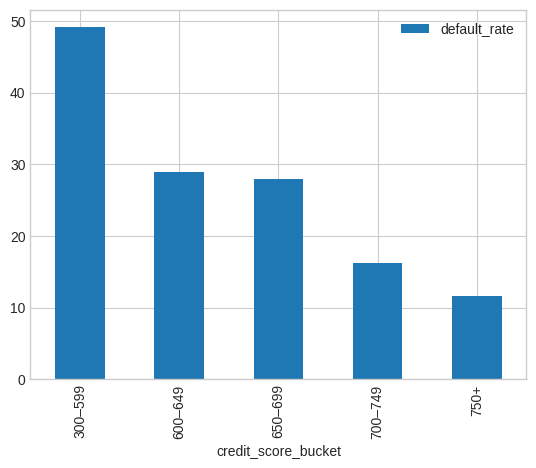

In [1990]:
credit_summary.plot(kind='bar', x='credit_score_bucket', y='default_rate')

In [1991]:

for bar, rate, total in zip(bars, credit_summary['default_rate'], credit_summary['total']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{rate}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
             f'n={total}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax1.set_title('Default Rate by Credit Score Range', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Credit Score Range', fontsize=10)
ax1.set_ylabel('Default Rate (%)', fontsize=10)
ax1.set_ylim(0, credit_summary['default_rate'].max() + 8)
ax1.tick_params(axis='x', rotation=15)

In [1992]:

for bar, rate, total in zip(bars, credit_summary['default_rate'], credit_summary['total']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{rate}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
             f'n={total}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax1.set_title('Default Rate by Credit Score Range', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Credit Score Range', fontsize=10)
ax1.set_ylabel('Default Rate (%)', fontsize=10)
ax1.set_ylim(0, credit_summary['default_rate'].max() + 8)
ax1.tick_params(axis='x', rotation=15)

In [1993]:

# Scatter Plot: DTI vs Default Status
ax2 = fig.add_subplot(2, 2, 2)

defaulted     = df3[df3['default_binary'] == 1]
non_defaulted = df3[df3['default_binary'] == 0]

ax2.scatter(non_defaulted['dti'], non_defaulted['credit_score'],
            alpha=0.4, c='#4575b4', s=25, label='No Default', zorder=2)
ax2.scatter(defaulted['dti'], defaulted['credit_score'],
            alpha=0.6, c='#d73027', s=25, label='Default', zorder=3)

# Mean lines
ax2.axvline(x=defaulted['dti'].mean(), color='#d73027',
            linestyle='--', linewidth=1.5, alpha=0.8,
            label=f"Default DTI mean: {defaulted['dti'].mean():.1f}%")
ax2.axvline(x=non_defaulted['dti'].mean(), color='#4575b4',
            linestyle='--', linewidth=1.5, alpha=0.8,
            label=f"No Default DTI mean: {non_defaulted['dti'].mean():.1f}%")

ax2.set_title('DTI vs Credit Score by Default Status', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Debt-to-Income Ratio (%)', fontsize=10)
ax2.set_ylabel('Credit Score', fontsize=10)
ax2.legend(fontsize=8, loc='upper right')

<Axes: xlabel='default_binary', ylabel='dti'>

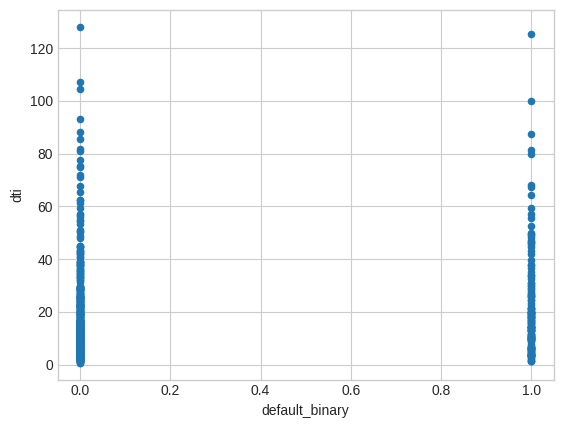

In [1994]:
df3.plot(kind='scatter', x='default_binary', y='dti')

In [1995]:
# Default Rate by Loan Purpose (Horizontal Bar Chart)
ax3 = fig.add_subplot(2, 2, 3)

purpose_summary = (df3.groupby('loan_purpose', observed=True)
                     .agg(total=('default_binary', 'count'),
                          defaults=('default_binary', 'sum'))
                     .assign(default_rate=lambda x: (x['defaults'] / x['total'] * 100).round(1))
                     .sort_values('default_rate', ascending=True)
                     .reset_index()
)

color_map    = plt.cm.RdYlGn_r
norm         = plt.Normalize(purpose_summary['default_rate'].min(),
                              purpose_summary['default_rate'].max())
colors_purp  = [color_map(norm(v)) for v in purpose_summary['default_rate']]

h_bars = ax3.barh(purpose_summary['loan_purpose'],
                  purpose_summary['default_rate'],
                  color=colors_purp, edgecolor='white', linewidth=0.8, height=0.6)

for bar, rate, total in zip(h_bars, purpose_summary['default_rate'], purpose_summary['total']):
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{rate}%  (n={total})', va='center', fontsize=9, fontweight='bold')

ax3.set_title('Default Rate by Loan Purpose', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Default Rate (%)', fontsize=10)
ax3.set_ylabel('Loan Purpose', fontsize=10)
ax3.set_xlim(0, purpose_summary['default_rate'].max() + 10)

(0.0, 42.1)

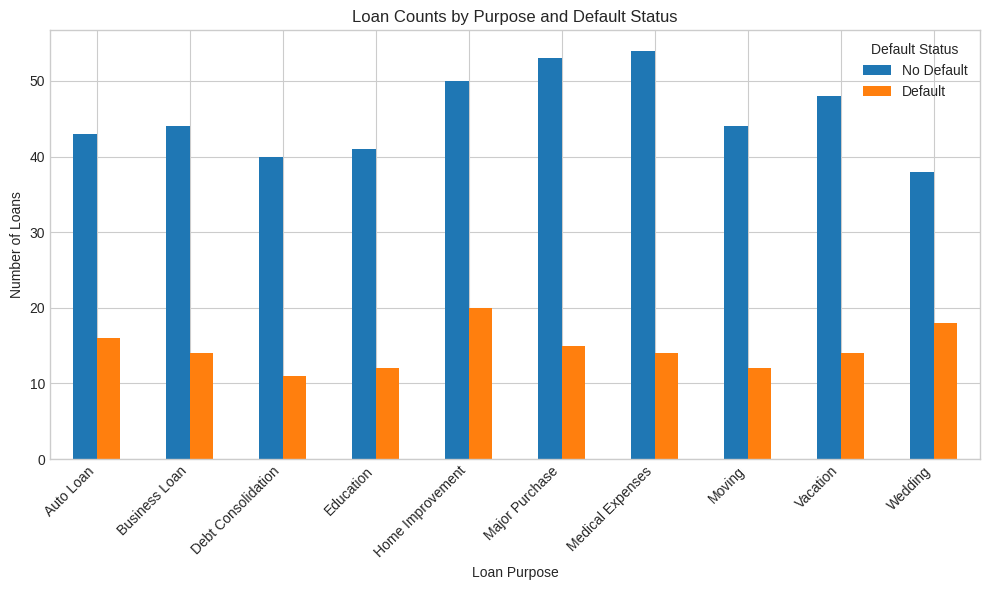

In [1996]:
loan_purpose_counts = df3.groupby('loan_purpose')['default_binary'].value_counts().unstack(fill_value=0)
loan_purpose_counts.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Loan Counts by Purpose and Default Status')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Default Status', labels=['No Default', 'Default'])
plt.tight_layout()
plt.show()

In [1999]:
#5.Recommendations:


In [1997]:
avg_loan_amount_by_purpose_default = df3.groupby(['loan_purpose', 'default_binary'])['loan_amount'].mean().unstack(fill_value=0)
print("\nAverage Loan Amount by Purpose and Default Status:")
print(avg_loan_amount_by_purpose_default)


Average Loan Amount by Purpose and Default Status:
default_binary                 0             1
loan_purpose                                  
Auto Loan           18404.651163  22643.750000
Business Loan       22479.545455  16407.142857
Debt Consolidation  21030.000000  29036.363636
Education           17114.634146  29183.333333
Home Improvement    25110.000000  19150.000000
Major Purchase      25141.509434  16180.000000
Medical Expenses    21298.148148  30421.428571
Moving              21115.909091  21975.000000
Vacation            24527.083333  24307.142857
Wedding             22313.157895  21005.555556


In [1998]:
less_than_2_years_employed = df3[df3['years_employed'] < 2]
total_loans_lt2 = less_than_2_years_employed.shape[0]
defaults_lt2 = less_than_2_years_employed['default_binary'].sum()
default_rate_lt2 = (defaults_lt2 / total_loans_lt2 * 100).round(2) if total_loans_lt2 > 0 else 0

print(f"\nDefault Rate for borrowers with less than 2 years of employment: {default_rate_lt2}% (n={total_loans_lt2})")

overall_default_rate_full = (df3['default_binary'].sum() / df3.shape[0] * 100).round(2)
print(f"Overall Default Rate: {overall_default_rate_full}% (n={df3.shape[0]})")


Default Rate for borrowers with less than 2 years of employment: 34.52% (n=84)
Overall Default Rate: 24.29% (n=601)


**Overall Default Rate:**

The overall default rate across all loan applications is 24.29%.

1. **Credit Score**:

Highest Risk Segment: The credit score range of 300–599 has the highest default rate at 49.14%.
Lower Risk Segments: Default rates significantly decrease with higher credit scores: 600–649 (29.03%), 650–699 (28.00%), 700–749 (16.28%), and 750+ (11.69%).

Recommendation:

Implement a minimum credit score threshold of 700. Loans to borrowers with credit scores below 700 should be subject to stricter scrutiny or additional qualifying criteria, given the notable increase in default rates below this threshold.

2. **Debt-to-Income (DTI) Ratio:**

Relationship: There is a clear relationship between DTI and default likelihood. Borrowers with a DTI of 45%+ exhibit a significantly higher default rate of 39.58%, compared to lower DTI ranges (e.g., 0–15% at 21.05%, 16–25% at 24.81%).

Recommendation:
Set a maximum DTI threshold of 45%. Applicants with DTI ratios exceeding 45% should generally be declined, or at minimum, require extensive additional risk mitigation factors.

**3. Loan Purpose:**

Highest Risk Purposes: Loans for Wedding (32.14%), Home Improvement (28.57%), and Auto Loan (27.12%) show the highest default rates.

Average Loan Amounts (Defaulted vs. Non-Defaulted): For some high-risk purposes, the average loan amount for defaulted loans is notably higher than for non-defaulted loans (e.g., Debt Consolidation: $29,036 for defaulted vs. $$29,036 for defaulted vs. $21,030 for non-defaulted; Education: $29,183 vs. $$29,183 vs. $17,114; Medical Expenses: $30,421 vs. $$30,421 vs. $21,298).

 However, for others, the pattern is reversed (e.g., Auto Loan: $22,643 vs. $$22,643 vs. $18,404 for defaulted vs. non-defaulted respectively). This suggests that higher loan amounts for specific purposes may be a contributing factor to default.

Recommendation:
Apply stricter underwriting standards or higher interest rates for loans purposed for Wedding, Home Improvement, Education, Debt Consolidation, and Medical Expenses, especially when the loan amount is higher than the average for that purpose.

Next Steps"